In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [6]:
base_dados = pd.read_csv('/content/Startups+in+2021+end.csv')

#verificar a dimensão
base_dados.shape

(936, 8)

In [11]:
base_dados.rename(columns={'Unnamed: 0': 'Id'}, inplace=True)

In [10]:
base_dados.head()

,Id,Company,Valuation ($B),Date Joined,Country,City,Industry,Select Investors
0,0,Bytedance,$140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,1,SpaceX,$100.3,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,2,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
3,3,Klarna,$45.6,12/12/2011,Sweden,Stockholm,Fintech,"Institutional Venture Partners, Sequoia Capita..."
4,4,Canva,$40,1/8/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."


In [ ]:
base_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 936 entries, 0 to 935
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Id                936 non-null    int64 
 1   Company           936 non-null    object
 2   Valuation ($B)    936 non-null    object
 3   Date Joined       936 non-null    object
 4   Country           936 non-null    object
 5   City              921 non-null    object
 6   Industry          936 non-null    object
 7   Select Investors  935 non-null    object
dtypes: int64(1), object(7)
memory usage: 58.6+ KB


In [ ]:
# campos unicos
base_dados.nunique()

,0
Id,936
Company,935
Valuation ($B),192
Date Joined,589
Country,47
City,239
Industry,17
Select Investors,920


In [ ]:
# valores unicos - rank
base_dados['Industry'].value_counts(normalize=True)

,proportion
Industry,
Fintech,0.202991
Internet software & services,0.178419
E-commerce & direct-to-consumer,0.108974
Artificial intelligence,0.073718
Health,0.067308
"Supply chain, logistics, & delivery",0.054487
Other,0.054487
Cybersecurity,0.043803
Mobile & telecommunications,0.039530


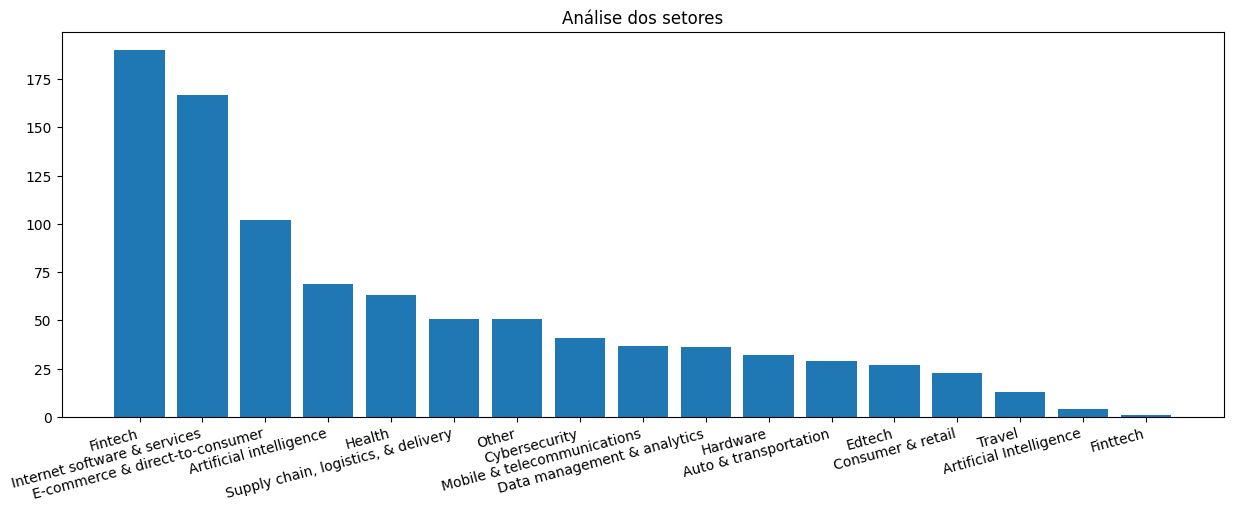

In [ ]:
plt.figure(figsize=(15,5))
plt.title('Análise dos setores')
plt.bar(base_dados['Industry'].value_counts().index, base_dados['Industry'].value_counts() )
#essa linha altera os nomes do eixo x:
plt.xticks(rotation=15, ha='right');

In [ ]:
base_dados['Country'].value_counts()

,count
Country,
United States,477
China,169
India,51
United Kingdom,37
Germany,23
Israel,21
France,19
Brazil,15
Canada,15


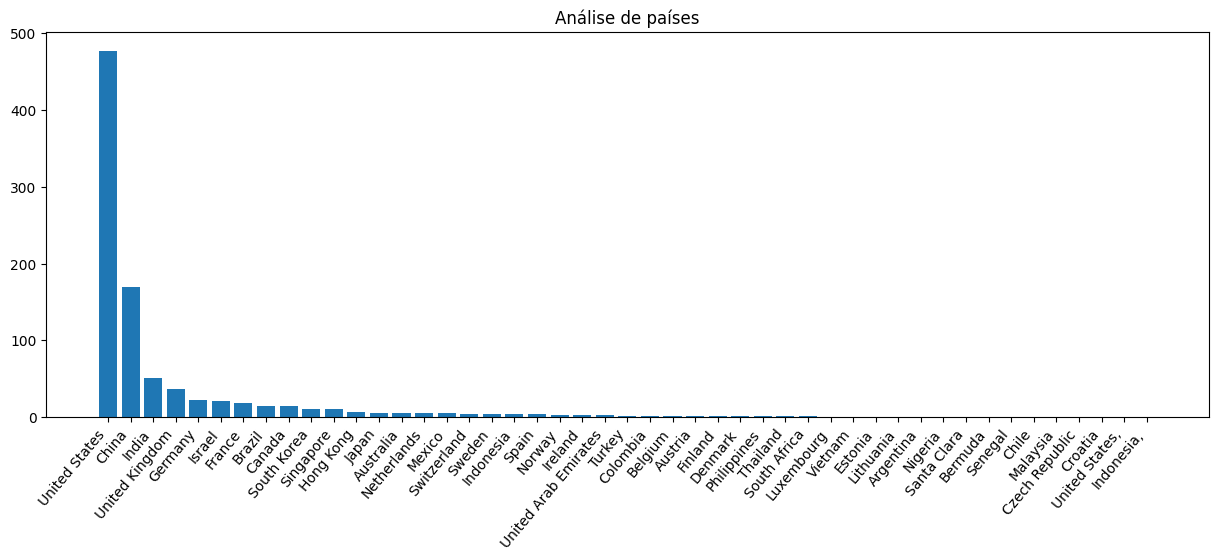

In [ ]:
plt.figure(figsize=(15,5))
plt.title('Análise de países')
plt.bar(base_dados['Country'].value_counts().index, base_dados['Country'].value_counts())
plt.xticks(rotation=50, ha='right');

In [ ]:
analise = base_dados['Country'].value_counts(normalize=True) * 100
analise

,proportion
Country,
United States,50.961538
China,18.055556
India,5.448718
United Kingdom,3.952991
Germany,2.457265
Israel,2.243590
France,2.029915
Brazil,1.602564
Canada,1.602564


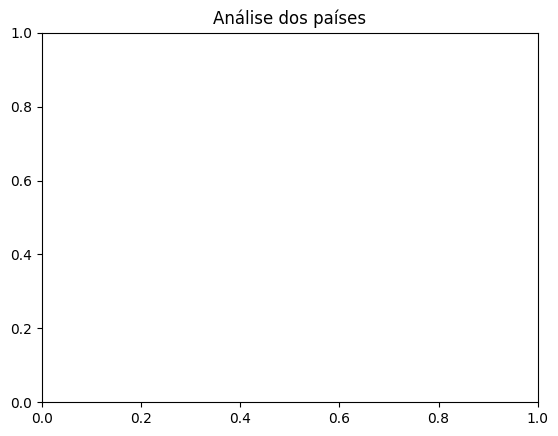

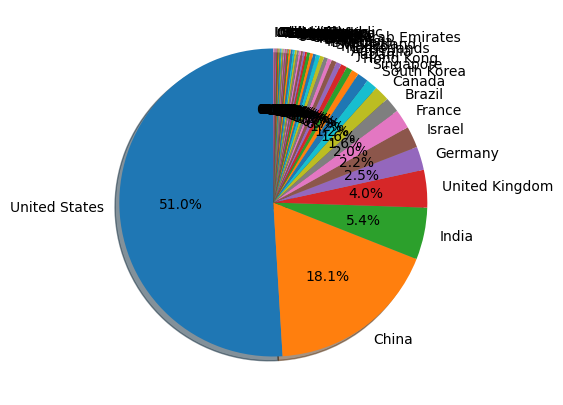

In [ ]:
# plot geral
plt.title('Análise dos países geradores de unicórnios')
plt.figure(figsize=(15,5))
plt.pie(
    analise,
    labels= analise.index,
    shadow=True,
    startangle=90,
    autopct='%1.1f%%'
);


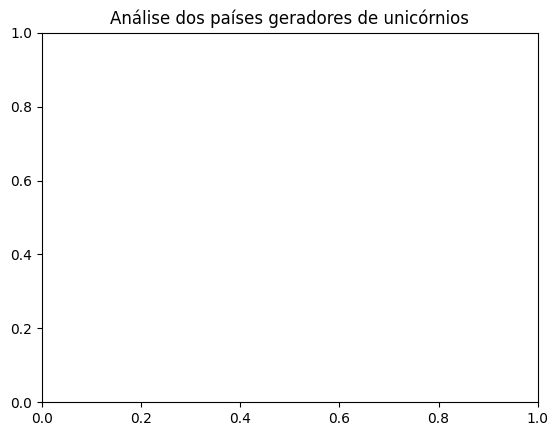

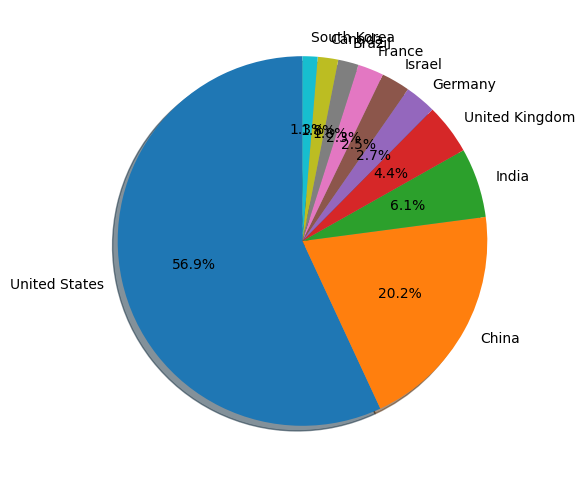

In [ ]:
plt.title('Análise dos países geradores de unicórnios')
plt.figure(figsize=(15,6))
plt.pie(
    analise.head(10),
    labels= analise.index[0:10],
    shadow=True,
    startangle=90,
    autopct='%1.1f%%'
);


In [ ]:
base_dados['Date Joined'] = pd.to_datetime(base_dados['Date Joined'])

base_dados['Date Joined'].head()

,Date Joined
0,2017-04-07
1,2012-12-01
2,2014-01-23
3,2011-12-12
4,2018-01-08


In [12]:
# extrair ano-mes
base_dados['Month'] = pd.DatetimeIndex(base_dados['Date Joined']).month
base_dados['Year'] = pd.DatetimeIndex(base_dados['Date Joined']).year
base_dados.head()
base_dados

,Id,Company,Valuation ($B),Date Joined,Country,City,Industry,Select Investors,Month,Year
0,0,Bytedance,$140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",4,2017
1,1,SpaceX,$100.3,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",12,2012
2,2,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",1,2014
3,3,Klarna,$45.6,12/12/2011,Sweden,Stockholm,Fintech,"Institutional Venture Partners, Sequoia Capita...",12,2011
4,4,Canva,$40,1/8/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat...",1,2018
...,...,...,...,...,...,...,...,...,...,...
931,931,YipitData,$1,12/6/2021,United States,New York,Internet software & services,"RRE Ventures+, Highland Capital Partners, The ...",12,2021
932,932,Anyscale,$1,12/7/2021,United States,Berkeley,Artificial Intelligence,"Andreessen Horowitz, Intel Capital, Foundation...",12,2021
933,933,Iodine Software,$1,12/1/2021,United States,Austin,Data management & analytics,"Advent International, Bain Capital Ventures, S...",12,2021
934,934,ReliaQuest,$1,12/1/2021,United States,Tampa,Cybersecurity,"KKR, FTV Capital, Ten Eleven Ventures",12,2021


In [18]:
#tabela analitica
analise_agrupada = base_dados.groupby(by=['Country', 'Year', 'Month', 'Company']).count()['Id'].reset_index()
analise_agrupada

,Country,Year,Month,Company,Id
0,Argentina,2021,8,Uala,1
1,Australia,2018,1,Canva,1
2,Australia,2019,3,Airwallex,1
3,Australia,2021,5,SafetyCulture,1
4,Australia,2021,7,Culture Amp,1
...,...,...,...,...,...
931,United States,2021,12,Panther Labs,1
932,United States,2021,12,ReliaQuest,1
933,United States,2021,12,YipitData,1
934,"United States,",2021,9,TrialSpark,1


In [19]:
analise_agrupada.loc[
    analise_agrupada['Country']== 'Brazil'
]

,Country,Year,Month,Company,Id
12,Brazil,2018,3,Nubank,1
13,Brazil,2018,7,Movile,1
14,Brazil,2018,11,iFood,1
15,Brazil,2019,6,Loggi,1
16,Brazil,2019,9,QuintoAndar,1
17,Brazil,2019,10,EBANX,1
18,Brazil,2019,12,Wildlife Studios,1
19,Brazil,2020,1,Loft,1
20,Brazil,2020,12,C6 Bank,1
21,Brazil,2020,12,Creditas,1


In [42]:
#transforma a coluna valuation
#pd.to_numeric(base_dados['Valuation ($B)'].apply(lambda linha: linha.replace('$', '')))
base_dados['Valuation ($B)']

,Valuation ($B)
0,140.0
1,100.3
2,95.0
3,45.6
4,40.0
...,...
931,1.0
932,1.0
933,1.0
934,1.0


In [51]:
#analise do valuation
analise_valuation = base_dados.groupby('Country').sum()['Valuation ($B)'].reset_index().sort_values('Valuation ($B)', ascending=False)
analise_valuation.head()

,Country,Valuation ($B)
44,United States,1604.03
8,China,569.48
43,United Kingdom,150.29
18,India,148.45
16,Germany,66.63


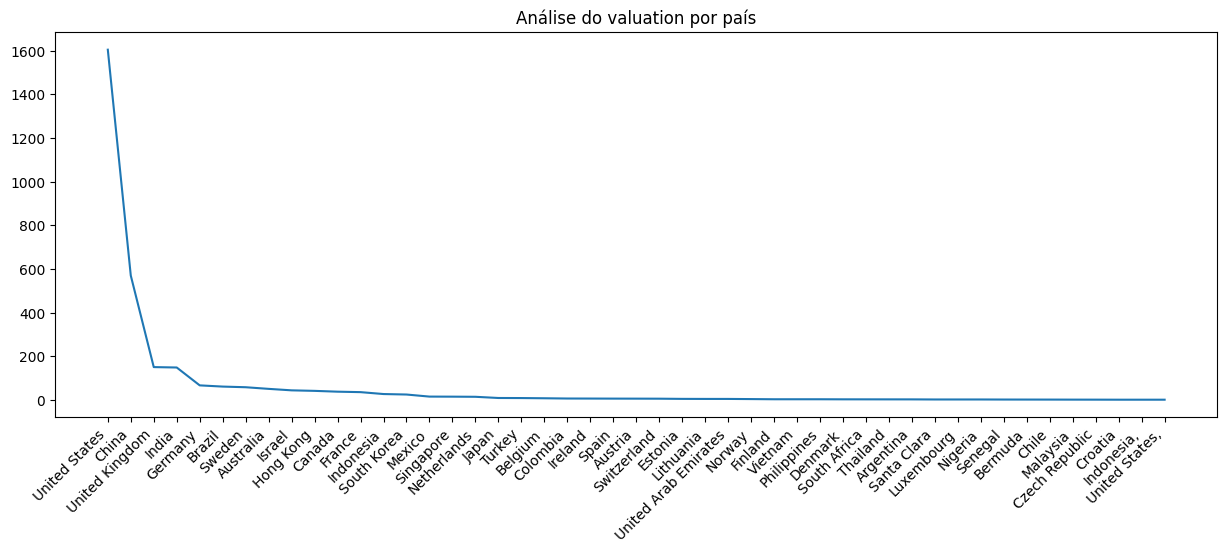

In [58]:
plt.figure(figsize=(15,5))
plt.plot( analise_valuation['Country'], analise_valuation['Valuation ($B)'])
plt.title('Análise do valuation por país')
plt.xticks(rotation=45, ha='right');
